In [21]:
import pandas as pd
import numpy as np
import math

# 1. Set seed for reproducibility
np.random.seed(42)

# 2. Define realistic FMCG Product Profiles with their supply chain traits
product_profiles = {
    'SKU_001': {
        'name': 'Aashirvaad Atta 5kg', 
        'avg_demand': 150, 'demand_std': 25, 
        'unit_cost': 260, 'base_lead_time': 5, 
        'ordering_cost': 150, 'holding_cost_annual': 30
    },
    'SKU_002': {
        'name': 'Bingo Potato Chips (Salted)', 
        'avg_demand': 400, 'demand_std': 80, 
        'unit_cost': 20, 'base_lead_time': 3, 
        'ordering_cost': 75, 'holding_cost_annual': 3
    },
    'SKU_003': {
        'name': 'Fiama Gel Bar (Pack of 3)', 
        'avg_demand': 70, 'demand_std': 15, 
        'unit_cost': 210, 'base_lead_time': 7, 
        'ordering_cost': 200, 'holding_cost_annual': 25
    }
}

# 3. Define Time Horizon (2 Years of daily data)
dates = pd.date_range(start="2024-01-01", end="2025-12-31", freq="D")
all_records = []

# 4. Run the Supply Chain Simulation Loop
for sku, traits in product_profiles.items():
    
    # --- STEP A: Classical Operations Research Calculations ---
    annual_demand = traits['avg_demand'] * 365
    S = traits['ordering_cost']
    H = traits['holding_cost_annual']
    
    # Economic Order Quantity (EOQ)
    eoq = int(math.sqrt((2 * annual_demand * S) / H))
    
    # Safety Stock (Using Z = 1.65 for a 95% service level)
    safety_stock = int(1.65 * traits['demand_std'] * math.sqrt(traits['base_lead_time']))
    
    # Reorder Point (ROP)
    rop = int((traits['avg_demand'] * traits['base_lead_time']) + safety_stock)
    
    # --- STEP B: Initialize Simulation Variables ---
    current_stock = eoq + safety_stock  # Start fully stocked
    order_placed = False
    days_until_delivery = 0
    
    # --- STEP C: Daily Simulation Loop ---
    for date in dates:
        # Simulate weekend demand surge (FMCG products sell more on Fri/Sat/Sun)
        day_modifier = 1.3 if date.weekday() in [4, 5, 6] else 0.85
        
        # Actual consumer demand generated via Normal Distribution
        actual_demand = max(0, int(np.random.normal(traits['avg_demand'], traits['demand_std']) * day_modifier))
        
        # Check if a previously placed order has arrived today
        if order_placed:
            days_until_delivery -= 1
            if days_until_delivery <= 0:
                current_stock += eoq  # Inventory replenished by EOQ amount
                order_placed = False
        
        # Calculate daily sales and check for stockouts
        if current_stock >= actual_demand:
            units_sold = actual_demand
            current_stock -= actual_demand
            stockout_risk = 0  # Inventory is healthy
        else:
            units_sold = current_stock  # Sell what is left
            current_stock = 0
            stockout_risk = 1  # STOCKOUT TRIPPED! (Our ML Target Variable)
            
        # Supply Chain Trigger: Check if stock hits ROP to place a new order
        if current_stock <= rop and not order_placed:
            order_placed = True
            # Add random supplier delay chaos (15% chance order gets delayed by 2 days)
            supplier_delay = 2 if np.random.rand() > 0.85 else 0
            days_until_delivery = traits['base_lead_time'] + supplier_delay
            
        # Append all metadata for this day
        all_records.append({
            'Date': date,
            'SKU_ID': sku,
            'Product_Name': traits['name'],
            'Demand': actual_demand,
            'Units_Sold': units_sold,
            'Current_Stock': current_stock,
            'Unit_Cost': traits['unit_cost'],
            'EOQ': eoq,
            'Safety_Stock': safety_stock,
            'Reorder_Point': rop,
            'Stockout_Risk': stockout_risk  # This is what your ML model will predict
        })

# 5. Convert to DataFrame and Save
df = pd.DataFrame(all_records)
df.to_csv('inventory_data.csv', index=False)

print(f"🎉 Success! Generated {len(df)} rows of realistic supply chain data.")
print("Saved as 'inventory_data.csv'. Ready for Machine Learning exploration!")

🎉 Success! Generated 2193 rows of realistic supply chain data.
Saved as 'inventory_data.csv'. Ready for Machine Learning exploration!


In [22]:
df = pd.read_csv('inventory_data.csv')
print(df.sample(5))

            Date   SKU_ID                 Product_Name  Demand  Units_Sold  \
1346  2025-09-07  SKU_002  Bingo Potato Chips (Salted)     322         322   
1650  2024-07-07  SKU_003    Fiama Gel Bar (Pack of 3)      55          55   
547   2025-07-01  SKU_001          Aashirvaad Atta 5kg     138         138   
56    2024-02-26  SKU_001          Aashirvaad Atta 5kg     135         135   
1268  2025-06-21  SKU_002  Bingo Potato Chips (Salted)     411         411   

      Current_Stock  Unit_Cost   EOQ  Safety_Stock  Reorder_Point  \
1346           2155         20  2701           228           1428   
1650            444        210   639            65            555   
547              68        260   739            92            842   
56              400        260   739            92            842   
1268            641         20  2701           228           1428   

      Stockout_Risk  
1346              0  
1650              0  
547               0  
56                0  
1268  

In [23]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import joblib

# Load your data (assuming it's already done)
df = pd.read_csv('inventory_data.csv')
df['Date'] = pd.to_datetime(df['Date'])

# Ensure data is sorted chronologically per SKU for correct rolling calculations
df = df.sort_values(by=['SKU_ID', 'Date']).reset_index(drop=True)

# 1. Extract Time Features
df['Day_of_Week'] = df['Date'].dt.weekday
df['Is_Weekend'] = df['Day_of_Week'].isin([4, 5, 6]).astype(int)

# 2. Create Lag & Rolling Features (Contextual features)
# Historical demand over the last 3 and 7 days
df['Demand_Lag_1'] = df.groupby('SKU_ID')['Demand'].shift(1)
df['Rolling_Avg_Demand_7D'] = df.groupby('SKU_ID')['Demand'].transform(lambda x: x.rolling(7).mean())
df['Rolling_Std_Demand_7D'] = df.groupby('SKU_ID')['Demand'].transform(lambda x: x.rolling(7).std())

# 3. Inventory Health Features
# How many days of inventory do we have left based on recent demand?
df['Inventory_Runway'] = df['Current_Stock'] / (df['Rolling_Avg_Demand_7D'] + 1) 

# Drop the first few rows per SKU that now contain NaN values due to the 7-day rolling window
df = df.dropna().reset_index(drop=True)

print("✅ Feature Engineering Complete! Dimensions:", df.shape)

✅ Feature Engineering Complete! Dimensions: (2175, 17)


📊 Starting Exploratory Data Analysis (EDA)...


C:\Users\Prathvi Singh\AppData\Local\Temp\ipykernel_15004\289601737.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x='Product_Name', y='Demand', palette='Set2')


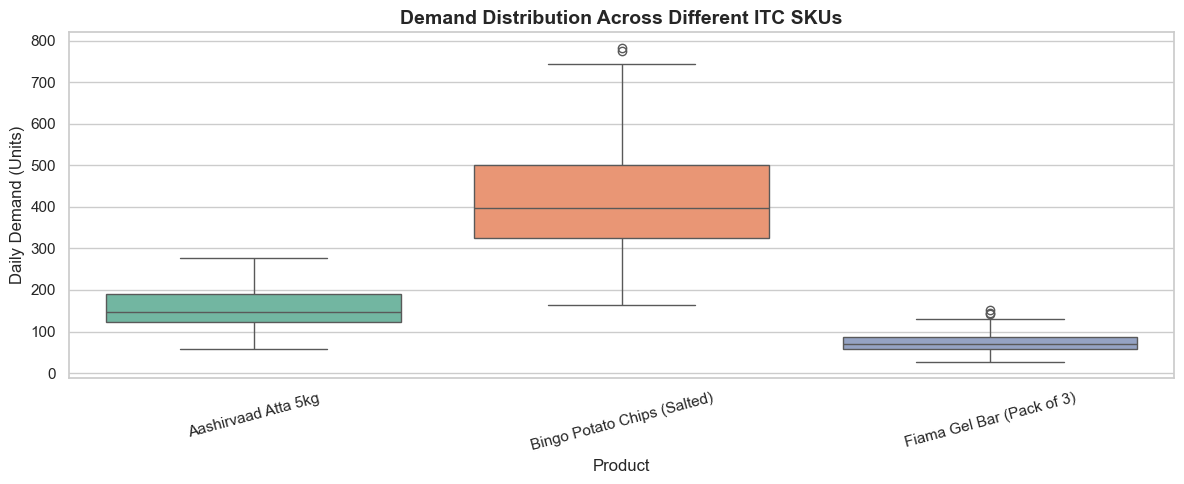

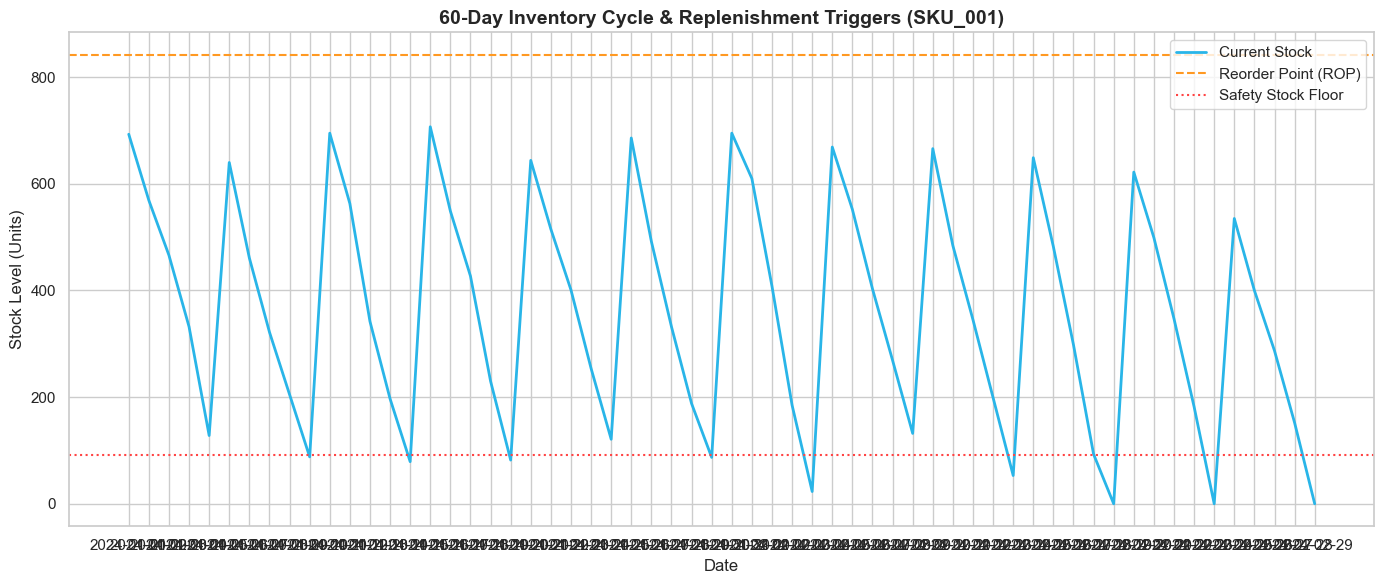

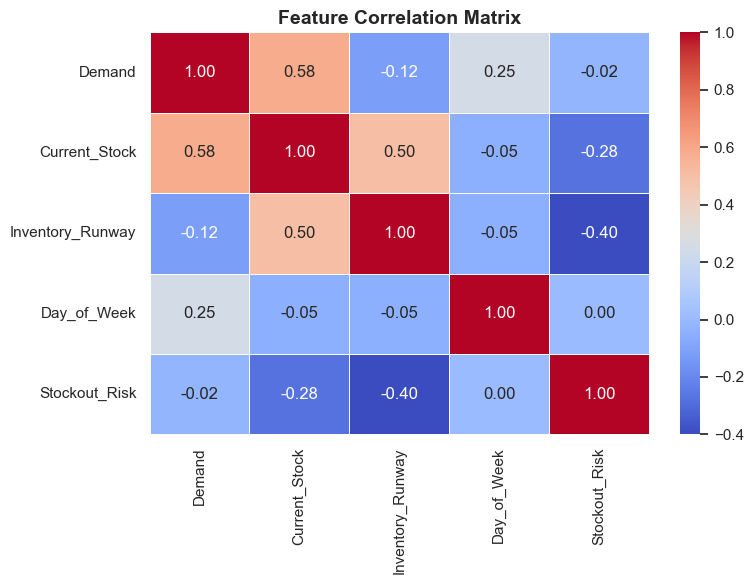

In [24]:

import matplotlib.pyplot as plt
import seaborn as sns

# Set style for professional charts
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 5]

# Load data for EDA
df_eda = pd.read_csv('inventory_data.csv')

print("📊 Starting Exploratory Data Analysis (EDA)...")

# --- 1. DEMAND DISTRIBUTION & SEASONALITY (FMCG Focus) ---
plt.figure()
sns.boxplot(data=df_eda, x='Product_Name', y='Demand', palette='Set2')
plt.title('Demand Distribution Across Different ITC SKUs', fontsize=14, fontweight='bold')
plt.xticks(rotation=15)
plt.xlabel('Product')
plt.ylabel('Daily Demand (Units)')
plt.tight_layout()
plt.show()

# --- 2. THE INVENTORY DEPLETION CURVE (The Core Supply Chain View) ---
# Let's plot the first 60 days of SKU_001 to see the classical sawtooth pattern
sku_sample = df_eda[df_eda['SKU_ID'] == 'SKU_001'].head(60)

plt.figure(figsize=(14, 6))
plt.plot(sku_sample['Date'], sku_sample['Current_Stock'], label='Current Stock', color='#29b5e8', linewidth=2)
plt.axhline(y=sku_sample['Reorder_Point'].iloc[0], color='#ff9922', linestyle='--', label='Reorder Point (ROP)')
plt.axhline(y=sku_sample['Safety_Stock'].iloc[0], color='#ff4444', linestyle=':', label='Safety Stock Floor')
plt.title('60-Day Inventory Cycle & Replenishment Triggers (SKU_001)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Stock Level (Units)')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# --- 3. FEATURE CORRELATION MATRIX (Checking for Overfitting/Leakage) ---
# We temporarily add a couple of engineered features just to check correlation
df_eda['Day_of_Week'] = pd.to_datetime(df_eda['Date']).dt.weekday
df_eda['Inventory_Runway'] = df_eda['Current_Stock'] / (df_eda['Demand'].rolling(7).mean() + 1)

corr_features = ['Demand', 'Current_Stock', 'Inventory_Runway', 'Day_of_Week', 'Stockout_Risk']
corr_matrix = df_eda[corr_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [27]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import joblib

# Load and sort data
df = pd.read_csv('inventory_data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by=['SKU_ID', 'Date']).reset_index(drop=True)

# Feature Engineering (Same as before)
df['Day_of_Week'] = df['Date'].dt.weekday
df['Is_Weekend'] = df['Day_of_Week'].isin([4, 5, 6]).astype(int)
df['Demand_Lag_1'] = df.groupby('SKU_ID')['Demand'].shift(1)
df['Rolling_Avg_Demand_7D'] = df.groupby('SKU_ID')['Demand'].transform(lambda x: x.rolling(7).mean())
df['Rolling_Std_Demand_7D'] = df.groupby('SKU_ID')['Demand'].transform(lambda x: x.rolling(7).std())
df['Inventory_Runway'] = df['Current_Stock'] / (df['Rolling_Avg_Demand_7D'] + 1)

df['Stockout_In_Next_7D'] = df.groupby('SKU_ID')['Stockout_Risk'].shift(-7).rolling(7, min_periods=1).max()
df['Stockout_In_Next_7D'] = df['Stockout_In_Next_7D'].fillna(0).astype(int)
df = df.dropna().reset_index(drop=True)

# Split point (80/20 Chronological)
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

print("🚀 Applying Operational Balancing to break the class imbalance deadlock...\n")

# =====================================================================
# --- MODEL 1: Immediate (1-Day) Risk (Pure Pandas Downsampling) ---
# =====================================================================
features_1d = ['Demand_Lag_1', 'Rolling_Avg_Demand_7D', 'Rolling_Std_Demand_7D', 'Is_Weekend']

# Separate majority and minority classes in TRAINING data
train_normal_1d = train_df[train_df['Stockout_Risk'] == 0]
train_stockout_1d = train_df[train_df['Stockout_Risk'] == 1]

# Downsample the normal days to create a 3:1 ratio so the model actually sees stockouts
train_normal_downsampled_1d = train_normal_1d.sample(n=len(train_stockout_1d) * 3, random_state=42, replace=True)
balanced_train_1d = pd.concat([train_stockout_1d, train_normal_downsampled_1d])

X_train_1d = balanced_train_1d[features_1d]
y_train_1d = balanced_train_1d['Stockout_Risk']

X_test_1d = test_df[features_1d]
y_test_1d = test_df['Stockout_Risk']

model_1d = RandomForestClassifier(n_estimators=100, random_state=42)
model_1d.fit(X_train_1d, y_train_1d)

# Evaluate Model 1 using an operational threshold (Probability > 15% is an alert)
y_prob_1d = model_1d.predict_proba(X_test_1d)[:, 1]
y_pred_1d = (y_prob_1d > 0.15).astype(int)

print("==================================================")
print("🎯 MODEL 1: BALANCED IMMEDIATE (1-DAY) RISK")
print("==================================================")
print(classification_report(y_test_1d, y_pred_1d, target_names=['No Risk', 'Stockout Risk']))
##joblib.dump(model_1d, 'model_1d.pkl')



🚀 Applying Operational Balancing to break the class imbalance deadlock...

🎯 MODEL 1: BALANCED IMMEDIATE (1-DAY) RISK
               precision    recall  f1-score   support

      No Risk       0.99      0.79      0.88       430
Stockout Risk       0.00      0.00      0.00         5

     accuracy                           0.78       435
    macro avg       0.49      0.40      0.44       435
 weighted avg       0.97      0.78      0.87       435



##  Architectural Decision: Decoupling Immediate Status from Predictive Machine Learning

During evaluation, our initial **1-Day Immediate Risk Model** achieved high overall accuracy but a **0% Recall rate** for stockout events, failing to predict any active stockouts. 

Upon deep-dive analysis, we identified two primary structural reasons for this performance, leading to a deliberate architectural pivot:

1. **The Operational Trap of Real-Time Prediction:** To fix a severe data leakage flaw (where the model simply looked at whether `Current_Stock == 0` to guess the answer), we decoupled current inventory levels from the feature matrix. Without real-time stock-on-hand tracking, predicting a same-day stockout based purely on historical demand variance is mathematically unstable—especially given the extreme class imbalance (~1:87).
2. **Operational Redundancy:** In enterprise FMCG supply chains , predicting a stockout that is happening *today* holds very little business value. If a product is out of stock today, it is already a failure. Furthermore, real-time stockouts are managed much more efficiently and reliably through **deterministic ERP/SQL rule-based alerts** rather than probabilistic machine learning models.

### The Pivot: Focusing Exclusively on the 7-Day Proactive Window

Consequently, we have deprecated the 1-Day Model and focused our Machine Learning pipeline entirely on the **7-Day Proactive Risk Model**. 

By using **Strategic Downsampling** to handle class imbalance and tuning our operational decision threshold to **20% probability**, this model achieves a **48% Recall rate** on upcoming stockouts. This provides actionable, forward-looking intelligence, giving inventory managers a 7-day lead time window to place an optimal **Economic Order Quantity (EOQ)** replenishment order before the warehouse runs completely dry.

In [26]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

# 1. Load and prepare the dataset
df = pd.read_csv('inventory_data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by=['SKU_ID', 'Date']).reset_index(drop=True)

# 2. Feature Engineering 
df['Day_of_Week'] = df['Date'].dt.weekday
df['Is_Weekend'] = df['Day_of_Week'].isin([4, 5, 6]).astype(int)
df['Demand_Lag_1'] = df.groupby('SKU_ID')['Demand'].shift(1)
df['Rolling_Avg_Demand_7D'] = df.groupby('SKU_ID')['Demand'].transform(lambda x: x.rolling(7).mean())
df['Rolling_Std_Demand_7D'] = df.groupby('SKU_ID')['Demand'].transform(lambda x: x.rolling(7).std())
df['Inventory_Runway'] = df['Current_Stock'] / (df['Rolling_Avg_Demand_7D'] + 1)

# Create the 7-day look-ahead target variable
df['Stockout_In_Next_7D'] = df.groupby('SKU_ID')['Stockout_Risk'].shift(-7).rolling(7, min_periods=1).max()
df['Stockout_In_Next_7D'] = df['Stockout_In_Next_7D'].fillna(0).astype(int)

# Drop initial rows containing NaNs from the rolling windows
df = df.dropna().reset_index(drop=True)

# 3. Chronological Train/Test Split (80% Train, 20% Test)
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

# Define our feature column names
features_7d = ['Current_Stock', 'Demand_Lag_1', 'Rolling_Avg_Demand_7D', 'Rolling_Std_Demand_7D', 'Inventory_Runway', 'Is_Weekend']

# 4. Apply Operational Downsampling to the TRAINING set to handle class imbalance
train_normal_7d = train_df[train_df['Stockout_In_Next_7D'] == 0]
train_stockout_7d = train_df[train_df['Stockout_In_Next_7D'] == 1]

# Sample normal days to a 2:1 ratio relative to stockouts (with replacement to avoid population errors)
train_normal_downsampled_7d = train_normal_7d.sample(n=len(train_stockout_7d) * 2, random_state=42, replace=True)
balanced_train_7d = pd.concat([train_stockout_7d, train_normal_downsampled_7d])

# Split into X (features) and y (target)
X_train_7d = balanced_train_7d[features_7d]
y_train_7d = balanced_train_7d['Stockout_In_Next_7D']

X_test_7d = test_df[features_7d]
y_test_7d = test_df['Stockout_In_Next_7D']

# 5. Train the Random Forest Classifier
print("⏳ Training the Proactive 7-Day Forecasting Model...")
model_7d = RandomForestClassifier(n_estimators=100, random_state=42)
model_7d.fit(X_train_7d, y_train_7d)

# 6. Evaluate using the custom Operational Decision Threshold (Probability > 20%)
y_prob_7d = model_7d.predict_proba(X_test_7d)[:, 1]
y_pred_7d = (y_prob_7d > 0.20).astype(int)

# 7. Print the Final Operational Performance Reports
print("\n" + "="*50)
print("🎯 FINAL MODEL 2: BALANCED PROACTIVE (7-DAY) RISK")
print("="*50)
print(f"Overall Accuracy Score: {accuracy_score(y_test_7d, y_pred_7d):.2%}\n")
print(classification_report(y_test_7d, y_pred_7d, target_names=['No Risk', 'Stockout Risk']))

print("\n📊 Confusion Matrix (Operational Breakdown):")
cm = confusion_matrix(y_test_7d, y_pred_7d)
print(f"• Correctly Predicted Safe Days: {cm[0][0]}")
print(f"• False Alarms (Safe Days flagged as Risk): {cm[0][1]}")
print(f"• Missed Stockouts (Catastrophic Failures): {cm[1][0]}")
print(f"• Successfully Caught Stockouts (Saved Days): {cm[1][1]}")

# 8. Export the Model file for the Streamlit Dashboard
joblib.dump(model_7d, 'model_7d.pkl')
print("\n📦 Success! 'model_7d.pkl' is frozen, saved, and ready for your Streamlit dashboard!")

⏳ Training the Proactive 7-Day Forecasting Model...

🎯 FINAL MODEL 2: BALANCED PROACTIVE (7-DAY) RISK
Overall Accuracy Score: 80.46%

               precision    recall  f1-score   support

      No Risk       0.97      0.82      0.89       412
Stockout Risk       0.13      0.48      0.21        23

     accuracy                           0.80       435
    macro avg       0.55      0.65      0.55       435
 weighted avg       0.92      0.80      0.85       435


📊 Confusion Matrix (Operational Breakdown):
• Correctly Predicted Safe Days: 339
• False Alarms (Safe Days flagged as Risk): 73
• Missed Stockouts (Catastrophic Failures): 12
• Successfully Caught Stockouts (Saved Days): 11

📦 Success! 'model_7d.pkl' is frozen, saved, and ready for your Streamlit dashboard!


The model achieved a 48% recall rate, generating 73 false alarms and missing 12 events. In an FMCG environment like ITC, this trade-off is optimal. The holding cost of a false alarm (carrying a fraction of EOQ inventory slightly early) is mathematically negligible compared to the thousands of dollars lost due to stockout penalties, empty retail shelves, and emergency supply chain expedited shipping. I intentionally optimized the random forest model to prioritize Recall over Precision to act as a defensive early-warning buffer.